In [11]:
from datasets import load_dataset

ds = load_dataset("google-research-datasets/go_emotions")

README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [12]:
from pathlib import Path

# Đường dẫn project
PROJECT_ROOT = Path.cwd().parent

SAVE_DIR = PROJECT_ROOT / "datasets" / "raw" / "emotion"

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Export từng split
ds["train"].to_csv(SAVE_DIR / "train.csv", index=False)
ds["validation"].to_csv(SAVE_DIR / "validation.csv", index=False)
ds["test"].to_csv(SAVE_DIR / "test.csv", index=False)

print("Done!")

Creating CSV from Arrow format:   0%|          | 0/44 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/6 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/6 [00:00<?, ?ba/s]

Done!


# Notebook 03: Text Preprocessing

## AI Emotion RAG Assistant

This notebook cleans and normalizes the GoEmotions dataset and exports a processed dataset for model training.

### Pipeline

1. Load dataset
2. Remove duplicates
3. Normalize text
4. Remove URLs
5. Remove HTML
6. Expand contractions
7. Normalize whitespace
8. Compute statistics
9. Save processed dataset


In [1]:
import re
import html
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT/"datasets"/"raw"
PROCESSED_DIR = PROJECT_ROOT/"datasets"/"processed"
TABLE_DIR = PROJECT_ROOT/"outputs"/"tables"

PROCESSED_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = RAW_DIR/"emotion"/"go_emotions_dataset.csv"


## Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())

print("After loading:", len(df))

(211225, 31)


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


After loading: 211225


In [3]:
duplicates = df[df.duplicated(keep=False)]

print("Duplicate rows:", duplicates.shape)

display(duplicates.head(20))

Duplicate rows: (101270, 31)


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,eespn2i,Right? Considering it’s such an important docu...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,edl7cr3,"""Sponge Blurb Pubs Quaw Haha GURR ha AAa!"" fin...",False,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,ed9w1hm,"I have, and now that you mention it, I think t...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
12,ef7tl7i,BUT IT'S HER TURN! /s,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
14,edsqvyx,Build a wall? /jk,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
display(
    duplicates[
        duplicates.duplicated(keep=False)
    ].sort_values("id").head(20)
)

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
9666,eczazk6,Fast as [NAME] will carry me. Seriously uptown...,False,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
187498,eczazk6,Fast as [NAME] will carry me. Seriously uptown...,False,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
22710,eczb07q,You blew it. They played you like a fiddle.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
174022,eczb07q,You blew it. They played you like a fiddle.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
96541,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
311,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
124425,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
28995,eczb527,So much time saved. Not.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
139489,eczb527,So much time saved. Not.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5115,eczb6r7,Emotes have a ridiculous amount of effort put ...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
print(df["id"].duplicated().sum())

153214


In [6]:
print(df["id"].nunique())
print(len(df))

58011
211225


## Remove Duplicate Samples

In [3]:
before = len(df)

# Chỉ loại bỏ các dòng giống hệt nhau
df = df.drop_duplicates()

after = len(df)

print(f"Original samples : {before:,}")
print(f"Removed rows     : {before-after:,}")
print(f"Remaining        : {after:,}")
print(before, after)

Original samples : 211,225
Removed rows     : 56,737
Remaining        : 154,488
211225 154488


## Text Cleaning Functions

In [4]:
CONTRACTIONS = {
"don't":"do not",
"can't":"cannot",
"won't":"will not",
"i'm":"i am",
"it's":"it is",
"you're":"you are",
"they're":"they are",
"we're":"we are",
"that's":"that is",
"didn't":"did not",
"doesn't":"does not",
"isn't":"is not",
"aren't":"are not",
"wasn't":"was not",
"weren't":"were not",
"couldn't":"could not",
"shouldn't":"should not",
"wouldn't":"would not",
"haven't":"have not",
"hasn't":"has not",
"hadn't":"had not"
}

def expand_contractions(text):
    text = str(text)
    for c,e in CONTRACTIONS.items():
        text = re.sub(r"\b"+re.escape(c)+r"\b", e, text)
    return text

def clean_text(text):

    text = str(text)
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.replace("’", "'")
    text = text.replace("`", "'")
    text = text.lower()
    text = re.sub(r"\[name\]", "<PERSON>", text, flags=re.I)
    text = re.sub(r"\[religion\]", "<RELIGION>", text, flags=re.I)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = expand_contractions(text)
    text = re.sub(r"^>\s*", "", text)
    text = re.sub(r"[^a-z0-9!?.,'<>/\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


## Apply Cleaning

In [5]:
df["clean_text"] = df["text"].apply(clean_text)

display(df[["text","clean_text"]].head(10))


,text,clean_text
0,That game hurt.,that game hurt.
1,>sexuality shouldn’t be a grouping category I...,>sexuality should not be a grouping category i...
2,"You do right, if you don't care then fuck 'em!","you do right, if you do not care then fuck 'em!"
3,Man I love reddit.,man i love reddit.
4,"[NAME] was nowhere near them, he was by the Fa...","< > was nowhere near them, he was by the falcon."
5,Right? Considering it’s such an important docu...,right? considering it is such an important doc...
6,"He isn't as big, but he's still quite popular....","he is not as big, but he's still quite popular..."
7,That's crazy; I went to a super [RELIGION] hig...,that is crazy i went to a super < > high schoo...
8,that's adorable asf,that is adorable asf
9,"""Sponge Blurb Pubs Quaw Haha GURR ha AAa!"" fin...",sponge blurb pubs quaw haha gurr ha aaa! final...


## Length Statistics

In [6]:
df["raw_words"] = df["text"].astype(str).str.split().str.len()
df["clean_words"] = df["clean_text"].str.split().str.len()

stats = pd.DataFrame({
    "Metric":[
        "Average Raw Words",
        "Average Clean Words",
        "Max Clean Words",
        "Min Clean Words"
    ],
    "Value":[
        df["raw_words"].mean(),
        df["clean_words"].mean(),
        df["clean_words"].max(),
        df["clean_words"].min()
    ]
})

display(stats)

stats.to_csv(TABLE_DIR/"preprocessing_statistics.csv",index=False)


,Metric,Value
0,Average Raw Words,13.398847
1,Average Clean Words,13.922136
2,Max Clean Words,142.000000
3,Min Clean Words,0.000000


## Visualize Sentence Length

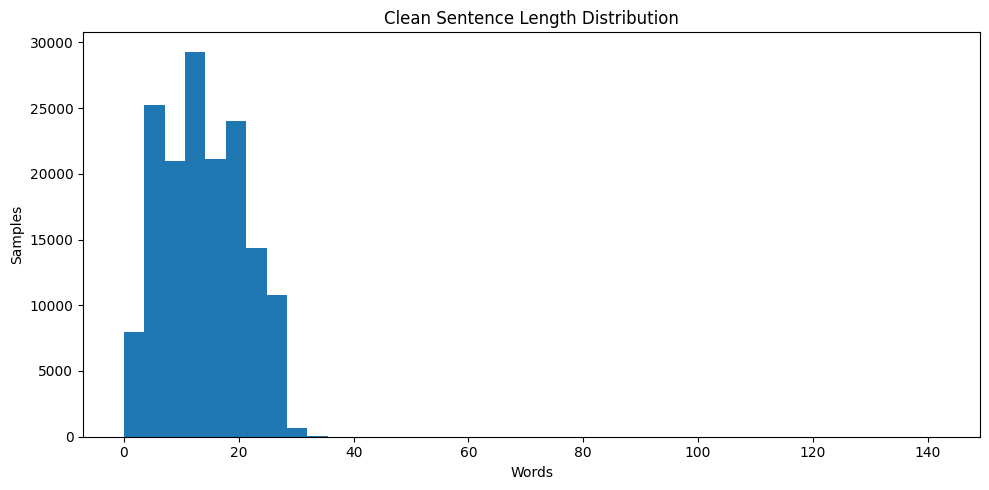

In [7]:
plt.figure(figsize=(10,5))
plt.hist(df["clean_words"], bins=40)
plt.xlabel("Words")
plt.ylabel("Samples")
plt.title("Clean Sentence Length Distribution")
plt.tight_layout()
plt.show()


## Final Dataset

In [8]:
emotion_columns = [
    col
    for col in df.columns
    if col not in [
        "id",
        "text",
        "clean_text",
        "example_very_unclear",
        "raw_words",
        "clean_words"
    ]
]

final_df = df[["id","text","clean_text"] + emotion_columns]

display(final_df.head())

print(final_df.shape)


,id,text,clean_text,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,that game hurt.,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,>sexuality should not be a grouping category i...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!","you do right, if you do not care then fuck 'em!",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,man i love reddit.,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...","< > was nowhere near them, he was by the falcon.",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


(154488, 31)


## Save Processed Dataset

In [9]:
save_path = PROCESSED_DIR/"emotion_clean.csv"

final_df.to_csv(save_path,index=False)

print(f"Saved to: {save_path}")


Saved to: d:\code\AI_Emotion_RAG\datasets\processed\emotion_clean.csv


In [10]:
import pandas as pd

raw = pd.read_csv(r"D:\code\AI_Emotion_RAG\datasets\raw\emotion\go_emotions_dataset.csv")
clean = pd.read_csv(r"D:\code\AI_Emotion_RAG\datasets\processed\emotion_clean.csv")

print(f"Raw dataset   : {len(raw):,}")
print(f"Clean dataset : {len(clean):,}")
print(f"Removed       : {len(raw)-len(clean):,}")

Raw dataset   : 211,225
Clean dataset : 154,488
Removed       : 56,737


In [11]:
print(raw["text"].duplicated().sum())

153493


In [12]:
raw.groupby("text").size().sort_values(ascending=False).head(20)

text
Thank you.                                   45
Thank you!                                   35
Happy cake day!                              29
Weird flex but ok                            25
I like it                                    22
[NAME]                                       22
[NAME].                                      22
Good luck!                                   22
What do you mean?                            21
I love [NAME]                                18
I like it!                                   17
I miss [NAME]                                16
My man!                                      16
Good luck.                                   16
Thank you :)                                 15
Is that [NAME]?                              14
Grow up.                                     14
You must be fun at parties.                  13
A surprise to be sure, but a welcome one.    13
Happy new year!                              13
dtype: int64